**Praktikum 2 (K-Means) Dataset bebas**

### **Import Library**

Langkah pertama adalah mengimpor semua library yang diperlukan untuk analisis data, visualisasi, dan clustering. Library yang diimpor meliputi `pandas` untuk manipulasi data, `numpy` untuk operasi numerik, `matplotlib.pyplot` dan `seaborn` untuk visualisasi, `sklearn.cluster.KMeans` untuk algoritma K-Means, serta `kagglehub` dan `KaggleDatasetAdapter` untuk mengunduh dataset dari Kaggle.

In [ ]:
!pip install kagglehub[pandas-datasets]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set_style("whitegrid")
print("Library berhasil diimpor!")

Library berhasil diimpor!


### **Memuat Dataset**

Setelah library diimpor, dataset 'Breast Cancer' dimuat dari Kaggle Hub menggunakan `kagglehub.load_dataset`. Dataset ini kemudian disimpan dalam DataFrame `df`. Lima baris pertama dari DataFrame ditampilkan untuk memberikan gambaran awal tentang struktur dan isi data.

In [ ]:
file_path = "data.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nancyalaswad90/breast-cancer-dataset",
  file_path
)

print("First 5 records:", df.head())

/tmp/ipykernel_325/1940366896.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'breast-cancer-dataset' dataset.
First 5 records:          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0

### **Melihat Jumlah Data**

Langkah ini bertujuan untuk mengetahui jumlah total baris atau entri dalam DataFrame `df`. Ini penting untuk memahami ukuran dataset yang sedang dianalisis.

In [ ]:
print(f"Jumlah Data dalam DataFrame: {df.shape[0]}")

Jumlah Data dalam DataFrame: 569


### **Menyiapkan Data untuk Clustering**

Untuk tujuan clustering, hanya dua fitur yang dipilih dari dataset: 'texture_mean' (variasi intensitas grayscale) dan 'concavity_mean' (luas rata-rata sel). Fitur-fitur ini disimpan dalam variabel `X` yang akan digunakan sebagai input untuk algoritma K-Means.

In [ ]:
X = df[['texture_mean', 'concavity_mean']].values

### **Set manual posisi centroid**

Langkah ini menentukan titik-titik centroid secara manual dan langkah ini opsional.

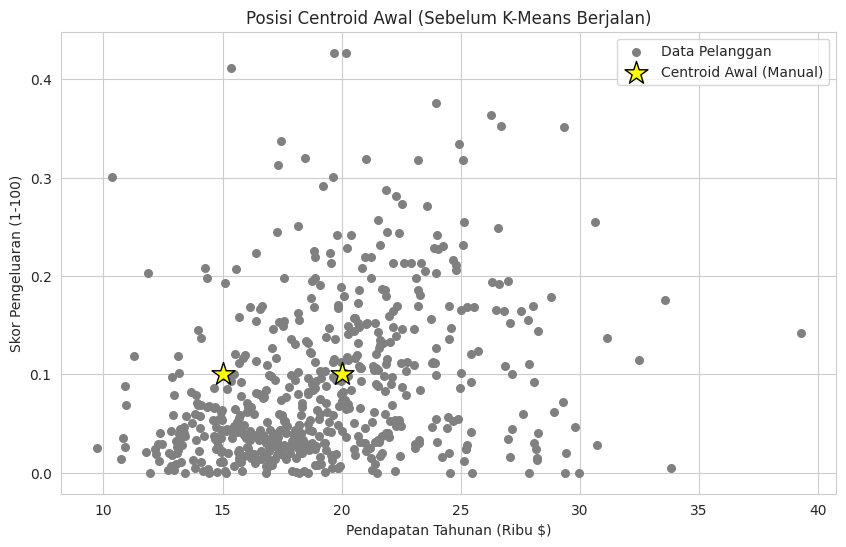

In [33]:
centroid_manual = np.array([
    [15, 0.1],
    [20, 0.1],
])

plt.figure(figsize=(10, 6))

plt.scatter(X[:, 0], X[:, 1], c='grey', s=30, label='Data Pelanggan')

plt.scatter(centroid_manual[:, 0], centroid_manual[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', label='Centroid Awal (Manual)')

plt.title('Posisi Centroid Awal (Sebelum K-Means Berjalan)')
plt.xlabel('Pendapatan Tahunan (Ribu $)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend()
plt.show()

### **Melakukan K-Means Clustering Awal (K=2)**

Pada langkah ini, algoritma K-Means diterapkan dengan asumsi awal 2 cluster (`n_clusters=2`). Data dalam `X` dikelompokkan, dan hasilnya divisualisasikan menggunakan scatter plot. Setiap cluster direpresentasikan dengan warna berbeda, dan centroid (pusat) dari setiap cluster ditandai dengan bintang kuning. Plot ini membantu memvisualisasikan bagaimana data dibagi menjadi dua kelompok berdasarkan fitur yang dipilih.

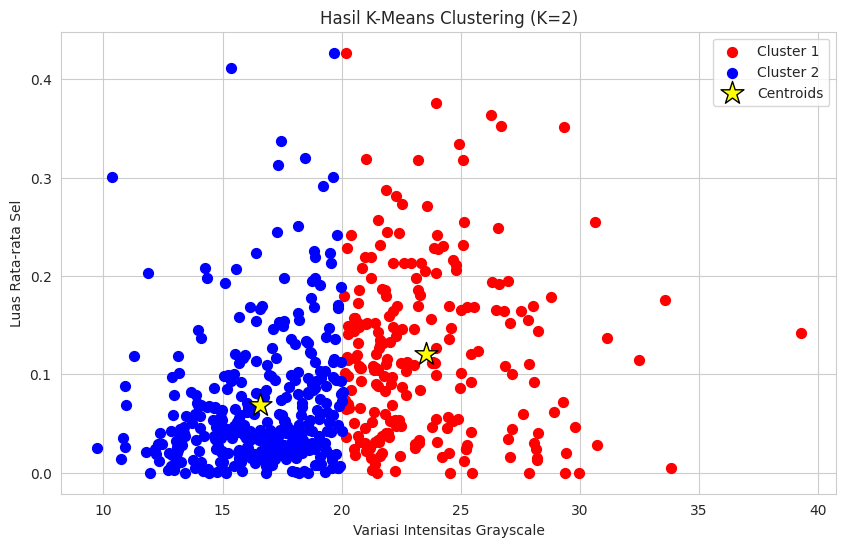

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1') # Menggambar titik-titik dalam cluster 1
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2') # Menggambar titik-titik dalam cluster 2

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('Hasil K-Means Clustering (K=2)')
plt.xlabel('Variasi Intensitas Grayscale')
plt.ylabel('Luas Rata-rata Sel')
plt.legend()
plt.show()

### **Menentukan Jumlah Cluster Optimal dengan Metode Elbow**

Metode Elbow digunakan untuk menentukan jumlah cluster (K) yang paling optimal. Dalam langkah ini, algoritma K-Means dijalankan untuk berbagai nilai K (dari 1 hingga 10). Untuk setiap nilai K, nilai WCSS (Within-Cluster Sum of Squares) dihitung dan disimpan. WCSS mengukur seberapa padat cluster; nilai WCSS yang lebih rendah menunjukkan cluster yang lebih baik. Grafik plot antara K dan WCSS kemudian dibuat untuk menemukan 'titik tekukan' (elbow) di mana penurunan WCSS mulai melandai, yang mengindikasikan nilai K optimal.

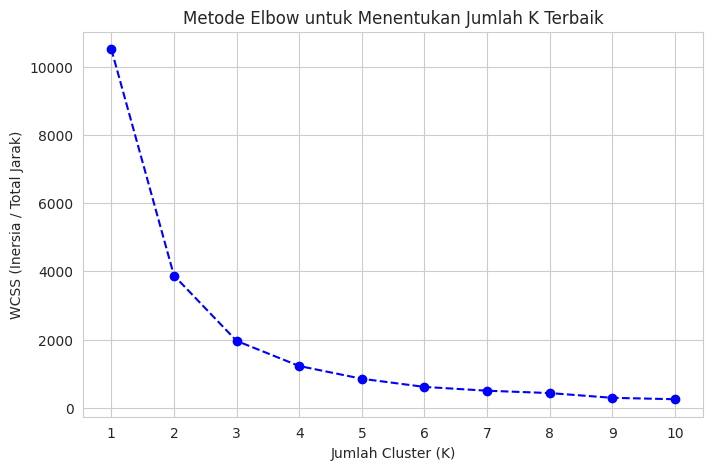

In [ ]:
wcss = []

for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow untuk Menentukan Jumlah K Terbaik')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inersia / Total Jarak)')
plt.xticks(range(1, 11))
plt.show()

### **Menerapkan K-Means Clustering dengan K Optimal (K=3)**

Berdasarkan hasil metode Elbow, jumlah cluster optimal yang teridentifikasi adalah K=3. Algoritma K-Means kemudian dilatih ulang dengan nilai K=3. Hasil clustering ini divisualisasikan kembali menggunakan scatter plot, menunjukkan pembagian data ke dalam tiga cluster yang dianggap optimal. Visualisasi ini memberikan representasi akhir dari pengelompokan data.

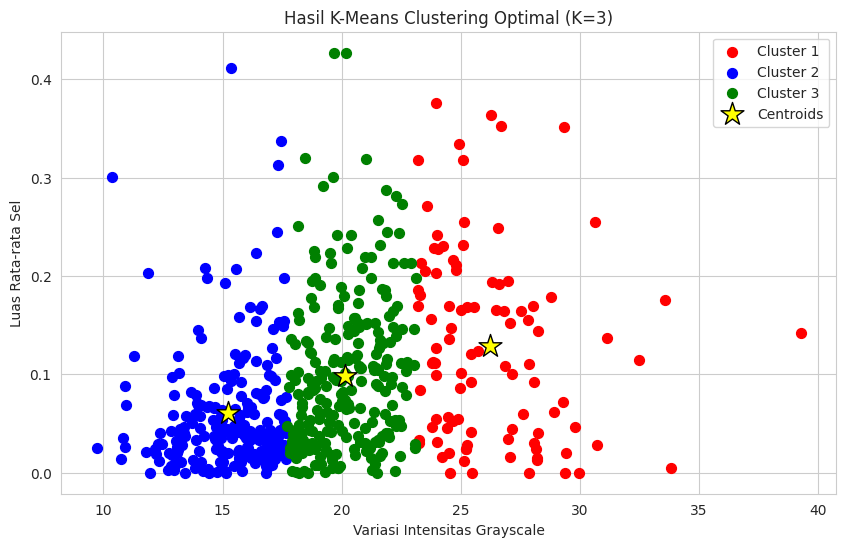

In [ ]:
# Melatih ulang model dengan K optimal hasil Elbow Method (K=3)
# Berdasarkan grafik elbow, titik tekukan (elbow) paling signifikan berada di K=3,
# di mana penurunan WCSS mulai melandai secara signifikan setelah K=3.
kmeans_ideal = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
y_kmeans_ideal = kmeans_ideal.fit_predict(X)

plt.figure(figsize=(10, 6))

plt.scatter(X[y_kmeans_ideal == 0, 0], X[y_kmeans_ideal == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans_ideal == 1, 0], X[y_kmeans_ideal == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans_ideal == 2, 0], X[y_kmeans_ideal == 2, 1], s=50, c='green', label='Cluster 3')

plt.scatter(kmeans_ideal.cluster_centers_[:, 0], kmeans_ideal.cluster_centers_[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('Hasil K-Means Clustering Optimal (K=3)')
plt.xlabel('Variasi Intensitas Grayscale')
plt.ylabel('Luas Rata-rata Sel')
plt.legend()
plt.show()

Berdasarkan hasil K-Means Clustering dengan K=3 yang ditentukan melalui Elbow Method, data sel kanker payudara berhasil dikelompokkan menjadi tiga cluster berdasarkan dua fitur utama, yaitu variasi intensitas grayscale (texture_mean) dan luas rata-rata sel (concavity_mean).

Cluster 1 (merah) mengelompokkan sel-sel yang memiliki variasi intensitas grayscale tinggi (di atas 22) dengan lekukan kontur sel yang cukup besar. Karakteristik ini mengindikasikan sel dengan tekstur yang tidak beraturan dan bentuk yang tidak normal, yang secara klinis lebih mengarah pada ciri-ciri sel ganas (malignant).

Cluster 2 (biru) merupakan kelompok terbesar yang menghimpun sel-sel dengan nilai texture_mean rendah (di bawah 17) dan concavity_mean yang kecil. Sel dalam kelompok ini memiliki tekstur yang lebih halus dan bentuk yang lebih teratur, sehingga lebih mencerminkan karakteristik sel jinak (benign).

Cluster 3 (hijau) berada di tengah-tengah kedua cluster sebelumnya, dengan nilai texture_mean berkisar antara 17 hingga 22 dan concavity_mean sedang. Kelompok ini merepresentasikan sel-sel yang berada dalam zona peralihan antara jinak dan ganas, sehingga memerlukan analisis lebih lanjut untuk menentukan klasifikasinya secara pasti.

Secara keseluruhan, hasil clustering ini menunjukkan bahwa algoritma K-Means mampu memisahkan data sel kanker payudara ke dalam kelompok-kelompok yang bermakna hanya berdasarkan pola data, tanpa menggunakan label diagnosis sebelumnya. Namun perlu digarisbawahi bahwa interpretasi medis dari hasil ini bersifat analitis dan bukan merupakan diagnosis klinis, sehingga validasi lebih lanjut dengan membandingkan hasil cluster terhadap label diagnosis asli tetap diperlukan.